# Load Intraday Auction Data (IDA)

In [5]:
import pandas as pd

In [6]:
dfs = []
for i in range(1, 53):
    df = pd.read_csv(f'energy-charts_Stromproduktion_und_Börsenstrompreise_in_Deutschland_in_Woche_{i}_2024.csv', 
                     sep=';', 
                     decimal=',',
                     header=None,
                     index_col=0
                    )
    df.sort_index(inplace=True) 
    dfs.append(df)

In [7]:
ida = pd.concat(dfs)

In [8]:
ida.head()

,1
0,
1.0,18.908018
2.0,7.136068
3.0,3.224757
4.0,1.080706
5.0,5.907751


In [9]:
# Set index manually (local time)
# Must be exaxctly 52 weeks = 34944 quarter-hours
ida.rename(columns={1: 'IDA'}, inplace=True)
ida.index = pd.date_range(start='2024-1-1 00:00', 
                         end='2024-12-29 23:45', 
                         freq='15min ')

In [10]:
ida.describe()

,IDA
count,34944.000000
mean,80.602270
std,68.709444
min,-171.985657
25%,54.520909
50%,78.877196
75%,102.684310
max,2326.287228


<AxesSubplot:>

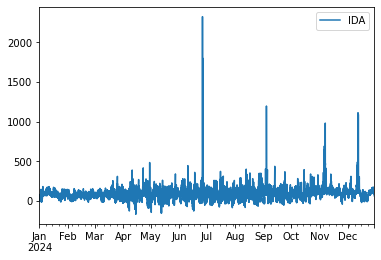

In [11]:
ida.plot()

In [12]:
ida.to_csv('2024_ida.csv')